In [1]:
import matplotlib.pyplot as plt

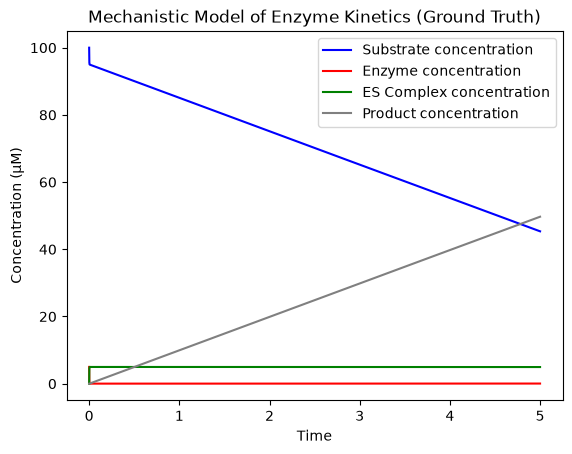

In [2]:
#Task 1 - Simulate the mechanistic model of a chemical reaction
#Variables used - Substrate (s), Enzyme (e), Complex (es), Product (p)
#Rate constants used - k1 (binding rate), k2 (dissociation rate), k3 (Catalysis)

s_conc = 100.0
e_conc = 5.0
p_conc = 0.0
es_conc = 0.0
dt = .0001
k1 = 10.0
k2 = k3 = 2.0
current_time = 0
time_coordinates = []
s_coordinates = []
e_coordinates = []
es_coordinates = []
p_coordinates = []
for i in range(50000):
    time_coordinates.append(current_time)
    s_coordinates.append(s_conc)
    e_coordinates.append(e_conc)
    es_coordinates.append(es_conc)
    p_coordinates .append(p_conc)
    ds = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt)
    de = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt) + (k3 * es_conc * dt)
    des = (k1 * e_conc * s_conc * dt) - (k2 * es_conc * dt) - (k3 * es_conc * dt)
    dp = (k3 * es_conc * dt)
    
    s_conc += ds
    e_conc += de
    es_conc += des
    p_conc += dp
    current_time += dt

plt.plot(time_coordinates, s_coordinates, label="Substrate concentration", color="blue")
plt.plot(time_coordinates, e_coordinates, label="Enzyme concentration", color="red")
plt.plot(time_coordinates, es_coordinates, label="ES Complex concentration", color="green")
plt.plot(time_coordinates, p_coordinates, label="Product concentration", color="grey")

plt.xlabel("Time")
plt.ylabel("Concentration (µM)")
plt.title("Mechanistic Model of Enzyme Kinetics (Ground Truth)")
plt.legend()
plt.show()




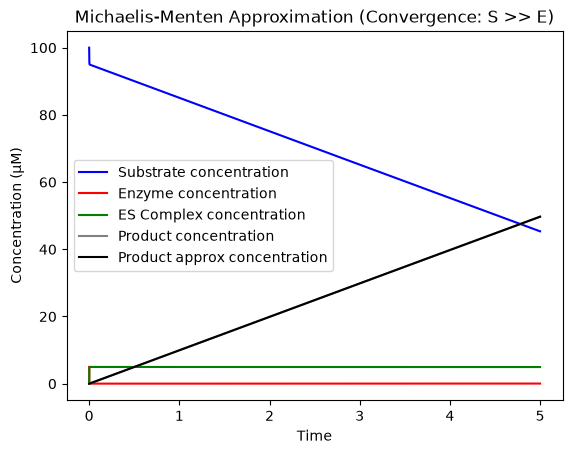

In [ ]:
#Task 2 - Simulate the michael menten equation
#Substrate >> Enzyme

s_conc = 100.0
e_conc = 5.0
p_conc = 0.0
es_conc = 0.0
p_approx = 0.0
dt = .0001
k1 = 10.0
k2 = k3 = 2.0
km = (k2 + k3)/k1
current_time = 0
time_coordinates = []
s_coordinates = []
e_coordinates = []
es_coordinates = []
p_coordinates = []
p_approx_coordinates = []
for i in range(50000):
    time_coordinates.append(current_time)
    s_coordinates.append(s_conc)
    e_coordinates.append(e_conc)
    es_coordinates.append(es_conc)
    p_coordinates .append(p_conc)
    p_approx_coordinates.append(p_approx)
    ds = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt)
    de = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt) + (k3 * es_conc * dt)
    des = (k1 * e_conc * s_conc * dt) - (k2 * es_conc * dt) - (k3 * es_conc * dt)
    dp = (k3 * es_conc * dt)
    vmax = k3 * (e_conc + es_conc)
    v = (vmax * s_conc)/(km + s_conc)
    dp_approx = v * dt
    
    s_conc += ds
    e_conc += de
    es_conc += des
    p_conc += dp
    p_approx += dp_approx
    current_time += dt

plt.plot(time_coordinates, s_coordinates, label="Substrate concentration", color="blue")
plt.plot(time_coordinates, e_coordinates, label="Enzyme concentration", color="red")
plt.plot(time_coordinates, es_coordinates, label="ES Complex concentration", color="green")
plt.plot(time_coordinates, p_coordinates, label="Product concentration", color="grey")
plt.plot(time_coordinates, p_approx_coordinates, label="Product approx concentration", color="black")

plt.xlabel("Time")
plt.ylabel("Concentration (µM)")
plt.title("Michaelis-Menten Approximation (Convergence: S >> E)")
plt.legend()
plt.show()




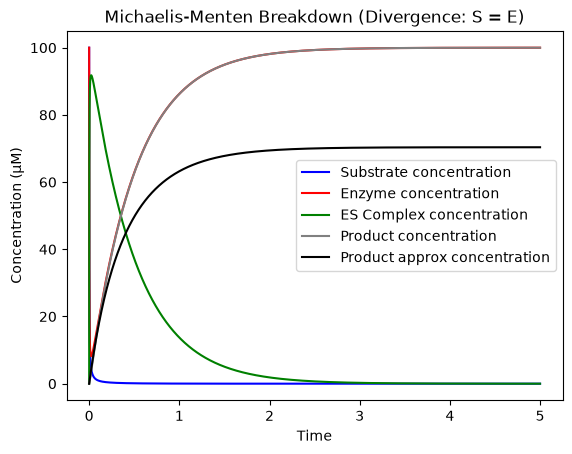

In [4]:
#Task 3 - Simulate the michael menten equation (Divergence)
#Putting enzyme and substrate initial concentration equal

s_conc = 100.0
e_conc = 100.0
p_conc = 0.0
es_conc = 0.0
p_approx = 0.0
dt = .0001
k1 = 10.0
k2 = k3 = 2.0
km = (k2 + k3)/k1
current_time = 0
time_coordinates = []
s_coordinates = []
e_coordinates = []
es_coordinates = []
p_coordinates = []
p_approx_coordinates = []
for i in range(50000):
    time_coordinates.append(current_time)
    s_coordinates.append(s_conc)
    e_coordinates.append(e_conc)
    es_coordinates.append(es_conc)
    p_coordinates .append(p_conc)
    p_approx_coordinates.append(p_approx)
    ds = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt)
    de = -(k1 * e_conc * s_conc * dt) + (k2 * es_conc * dt) + (k3 * es_conc * dt)
    des = (k1 * e_conc * s_conc * dt) - (k2 * es_conc * dt) - (k3 * es_conc * dt)
    dp = (k3 * es_conc * dt)
    vmax = k3 * (e_conc + es_conc)
    v = (vmax * s_conc)/(km + s_conc)
    dp_approx = v * dt
    
    s_conc += ds
    e_conc += de
    es_conc += des
    p_conc += dp
    p_approx += dp_approx
    current_time += dt

plt.plot(time_coordinates, s_coordinates, label="Substrate concentration", color="blue")
plt.plot(time_coordinates, e_coordinates, label="Enzyme concentration", color="red")
plt.plot(time_coordinates, es_coordinates, label="ES Complex concentration", color="green")
plt.plot(time_coordinates, p_coordinates, label="Product concentration", color="grey")
plt.plot(time_coordinates, p_approx_coordinates, label="Product approx concentration", color="black")

plt.xlabel("Time")
plt.ylabel("Concentration (µM)")
plt.title("Michaelis-Menten Breakdown (Divergence: S = E)")
plt.legend()
plt.show()


In [5]:
import matplotlib.pyplot as plt

def simulate_michael_menten(
    s_initial: float,
    e_initial: float,
    es_initial: 0.0,
    p_initial: 0.0,
    p_approx_initial: 0.0, 
    dt: float = 0.001, 
    k1: float = 10.0,
    k2: float = 2.0,
    k3: float = 2.0,
    steps: int = 10000
):
    km = (k2 + k3)/k1
    current_time = 0.0
    time_coordinates = []
    s_coordinates = []
    e_coordinates = []
    es_coordinates = []
    p_coordinates = []
    p_approx_coordinates = []

    for i in range(50000):
        time_coordinates.append(current_time)
        s_coordinates.append(s_initial)
        e_coordinates.append(e_initial)
        es_coordinates.append(es_initial)
        p_coordinates .append(p_initial)
        p_approx_coordinates.append(p_approx_initial)
        ds = -(k1 * e_initial * s_initial * dt) + (k2 * es_initial * dt)
        de = -(k1 * e_initial * s_initial * dt) + (k2 * es_initial * dt) + (k3 * es_initial * dt)
        des = (k1 * e_initial * s_initial * dt) - (k2 * es_initial* dt) - (k3 * es_initial * dt)
        dp = (k3 * es_initial * dt)
        vmax = k3 * (e_initial + es_initial)
        v = (vmax * s_initial)/(km + s_initial)
        dp_approx = v * dt
        
        s_initial += ds
        e_initial += de
        es_initial += des
        p_initial += dp
        p_approx_initial += dp_approx
        current_time += dt

    return time_coordinates, s_coordinates, e_coordinates, es_coordinates, p_coordinates, p_approx_coordinates, s_initial, e_initial, es_initial, p_initial, p_approx_initial

def plot_result(time_coordinates, s_coordinates, e_coordinates, es_coordinates, p_coordinates, p_approx_coordinates, s_initial, e_initial, es_initial, p_initial, p_approx_initial):
    plt.plot(time_coordinates, s_coordinates, label="Substrate concentration", color="blue")
    plt.plot(time_coordinates, e_coordinates, label="Enzyme concentration", color="red")
    plt.plot(time_coordinates, es_coordinates, label="ES Complex concentration", color="green")
    plt.plot(time_coordinates, p_coordinates, label="Product concentration", color="grey")
    plt.plot(time_coordinates, p_approx_coordinates, label="Product approx concentration", color="black")

    plt.xlabel("Time")
    plt.ylabel("Concentration (µM)")
    plt.title("Enzyme Kinetics Over Time")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [6]:
time_coord, s_coord, e_coord, es_coord, p_coord, p_approx_coord, s_start, e_start, es_start, p_start, p_approx_start = simulate_michael_menten(s_initial= 100.0,e_initial= 5.0, es_initial= 0.0, p_initial= 0.0, p_approx_initial= 0.0, dt = 0.001, 
    k1 = 10.0,
    k2 = 2.0,
    k3 = 2.0,
    steps = 10000)

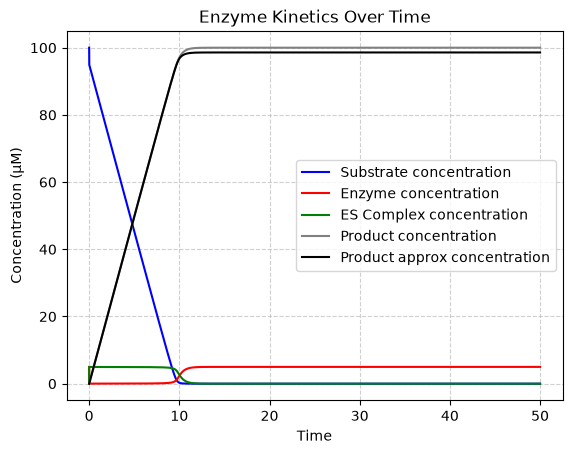

In [7]:
plot_result(time_coord, s_coord, e_coord, es_coord, p_coord, p_approx_coord, s_start, e_start, es_start, p_start, p_approx_start)